# Tutorial 02 - Exploring Segment Labels and Signal Quality

This notebook examines segment-level quality labels (`seg_masks`) and builds a transparent set of candidate clean segments for later spectral analysis.

## Learning goals
1. Inspect and count quality labels
2. Compare representative normal and artifact-labelled segments
3. Compute simple per-segment quality metrics
4. Define and export a reproducible clean-segment pool

In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path

mat_path = Path('..') / 'data' / 'MGH4J_sid001_1d8_20130718_075948.mat'
out_dir = Path('..') / 'outputs'
out_dir.mkdir(parents=True, exist_ok=True)

mat = sio.loadmat(str(mat_path), squeeze_me=True, struct_as_record=False)
bipolar = np.asarray(mat['EEG_segs_bipolar'])
seg_start_ids = np.asarray(mat['seg_start_ids']).astype(int).ravel()
seg_labels = [str(x).strip() for x in np.asarray(mat['seg_masks']).ravel()]
channel_names = [str(x).strip() for x in np.asarray(mat['channel_names']).ravel()]
Fs = float(mat['Fs'])

print('Loaded:', mat_path.resolve())
print('bipolar shape:', bipolar.shape)
print('Fs:', Fs)

Loaded: /Users/k2477067/Documents/Repos/Aperiodic_EEG_Modelling/data/MGH4J_sid001_1d8_20130718_075948.mat
bipolar shape: (10000, 18, 1000)
Fs: 200.0


## 1) Inspect and count `seg_masks` labels

`seg_masks` contains one string label per 5-second segment. We begin by counting all unique labels.

In [2]:
label_counts = pd.Series(seg_labels, name='label').value_counts().rename_axis('label').reset_index(name='count')
label_counts['percent'] = 100 * label_counts['count'] / len(seg_labels)
label_counts.head(20)

,label,count,percent
0,normal,7284,72.84
1,flat signal_[ 0 1 2 3 4 5 6 7 8 9 10 ...,780,7.80
2,flat signal_[7],73,0.73
3,flat signal_[2],70,0.70
4,flat signal_[13],66,0.66
5,flat signal_[3],64,0.64
6,flat signal_[14],52,0.52
7,flat signal_[16],52,0.52
8,spurious spectrum,47,0.47
9,flat signal_[ 7 13],40,0.40


/var/folders/dh/kbd41xgs21s3lms3cgc7_t1w0000gr/T/ipykernel_72476/2239178431.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


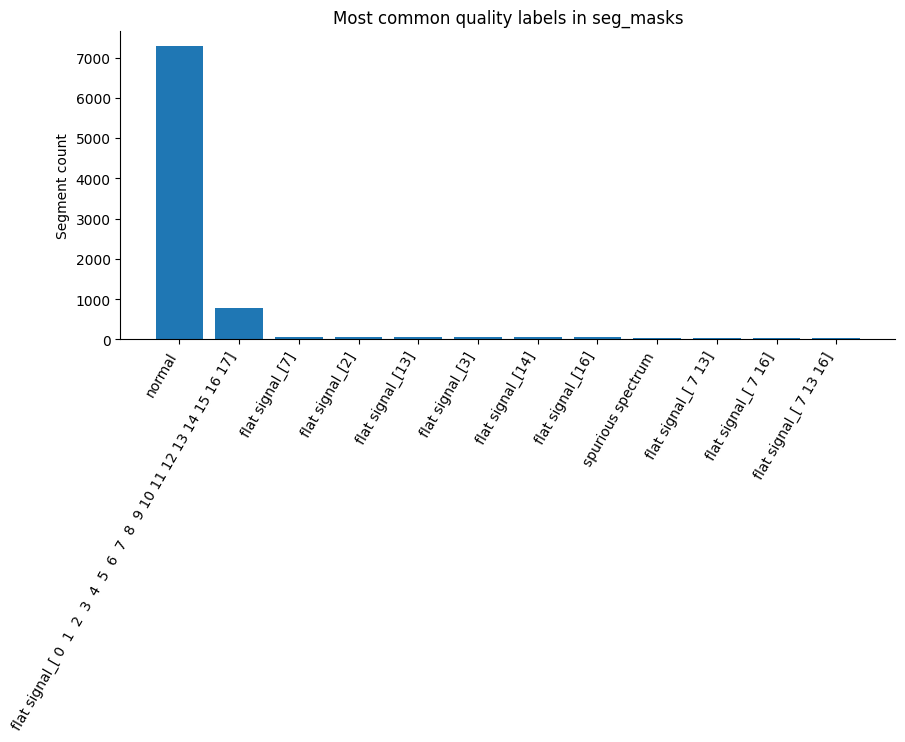

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
top_n = min(12, len(label_counts))
ax.bar(np.arange(top_n), label_counts.loc[:top_n - 1, 'count'])
ax.set_xticks(np.arange(top_n))
ax.set_xticklabels(label_counts.loc[:top_n - 1, 'label'], rotation=60, ha='right')
ax.set_ylabel('Segment count')
ax.set_title('Most common quality labels in seg_masks')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 2) Compare representative normal vs artifact segments

We select one `normal` segment and one non-normal segment, then plot all 18 channels with vertical offsets.

normal_idx: 1 label: normal
artifact_idx: 0 label: flat signal_[ 9 15]


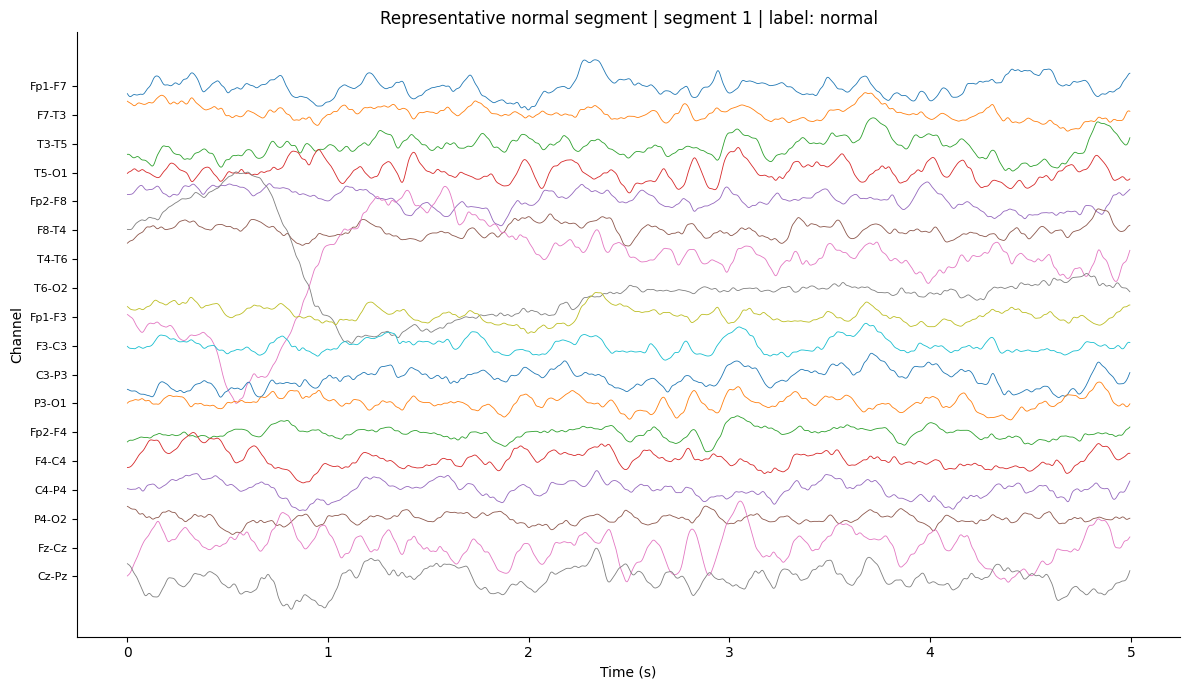

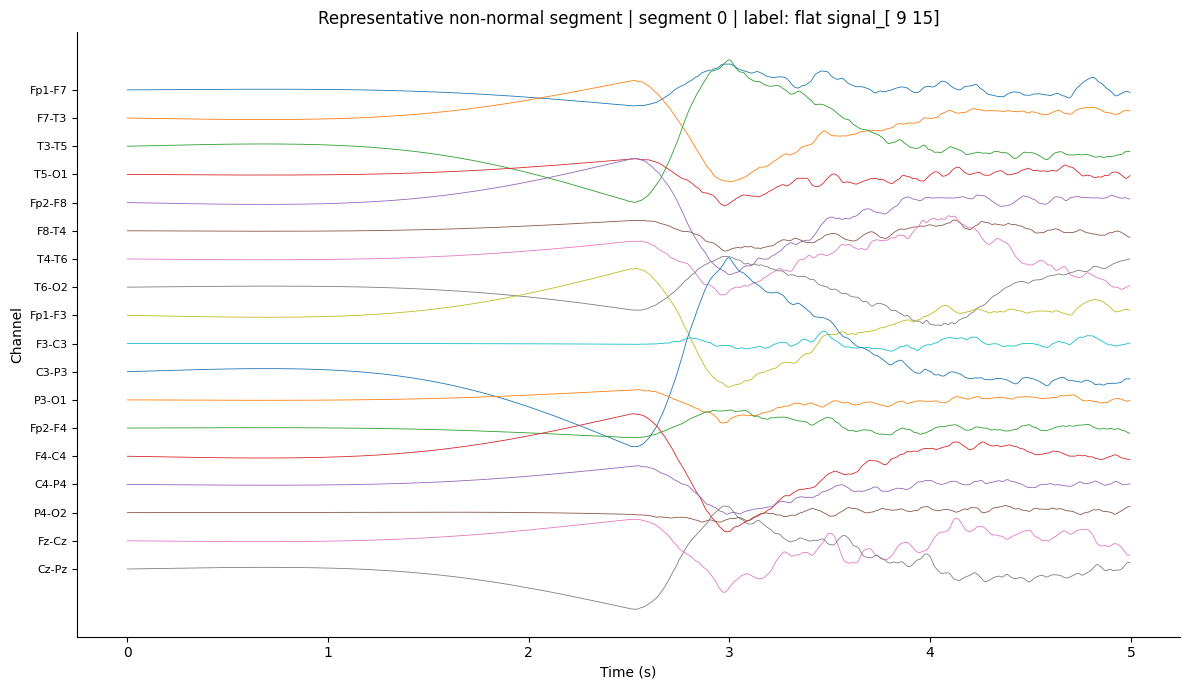

In [4]:
normal_idx = next(i for i, lbl in enumerate(seg_labels) if lbl == 'normal')
artifact_idx = next(i for i, lbl in enumerate(seg_labels) if lbl != 'normal')

print('normal_idx:', normal_idx, 'label:', seg_labels[normal_idx])
print('artifact_idx:', artifact_idx, 'label:', seg_labels[artifact_idx])

time = np.arange(bipolar.shape[2]) / Fs

def plot_segment_all_channels(seg_idx, title_prefix):
    data = bipolar[seg_idx]
    mad = np.median(np.abs(data - np.median(data, axis=1, keepdims=True)), axis=1)
    spacing = 5.0 * float(np.median(mad))
    fig, ax = plt.subplots(figsize=(12, 7))
    for ch in range(data.shape[0]):
        offset = (data.shape[0] - 1 - ch) * spacing
        ax.plot(time, data[ch] + offset, linewidth=0.6)
    ytick_pos = [(data.shape[0] - 1 - i) * spacing for i in range(data.shape[0])]
    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(channel_names, fontsize=8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Channel')
    ax.set_title(f'{title_prefix} | segment {seg_idx} | label: {seg_labels[seg_idx]}')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_segment_all_channels(normal_idx, 'Representative normal segment')
plot_segment_all_channels(artifact_idx, 'Representative non-normal segment')

## 3) Compute simple per-segment quality metrics

We compute transparent metrics per segment (aggregated across channels):
- RMS amplitude
- Standard deviation
- Peak-to-peak range
- Line length (mean absolute first difference)

These are not perfect artifact detectors; they are simple summaries students can inspect and modify.

In [5]:
rms = np.sqrt(np.mean(bipolar ** 2, axis=2))
std = np.std(bipolar, axis=2)
ptp = np.ptp(bipolar, axis=2)
line_len = np.mean(np.abs(np.diff(bipolar, axis=2)), axis=2)

quality_df = pd.DataFrame({
    'segment_index': np.arange(bipolar.shape[0]),
    'start_sample': seg_start_ids,
    'start_time_s': seg_start_ids / Fs,
    'label': seg_labels,
    'rms_median_ch': np.median(rms, axis=1),
    'std_median_ch': np.median(std, axis=1),
    'ptp_median_ch': np.median(ptp, axis=1),
    'line_length_median_ch': np.median(line_len, axis=1),
})

quality_df.head()

,segment_index,start_sample,start_time_s,label,rms_median_ch,std_median_ch,ptp_median_ch,line_length_median_ch
0,0,0,0.0,flat signal_[ 9 15],15.774533,15.668745,76.726562,0.284533
1,1,1000,5.0,normal,4.681343,4.635079,22.816406,0.372285
2,2,2000,10.0,normal,3.718803,3.710024,19.921875,0.398127
3,3,3000,15.0,normal,3.492342,3.485108,18.500000,0.344680
4,4,4000,20.0,normal,3.913951,3.913832,20.597656,0.355904


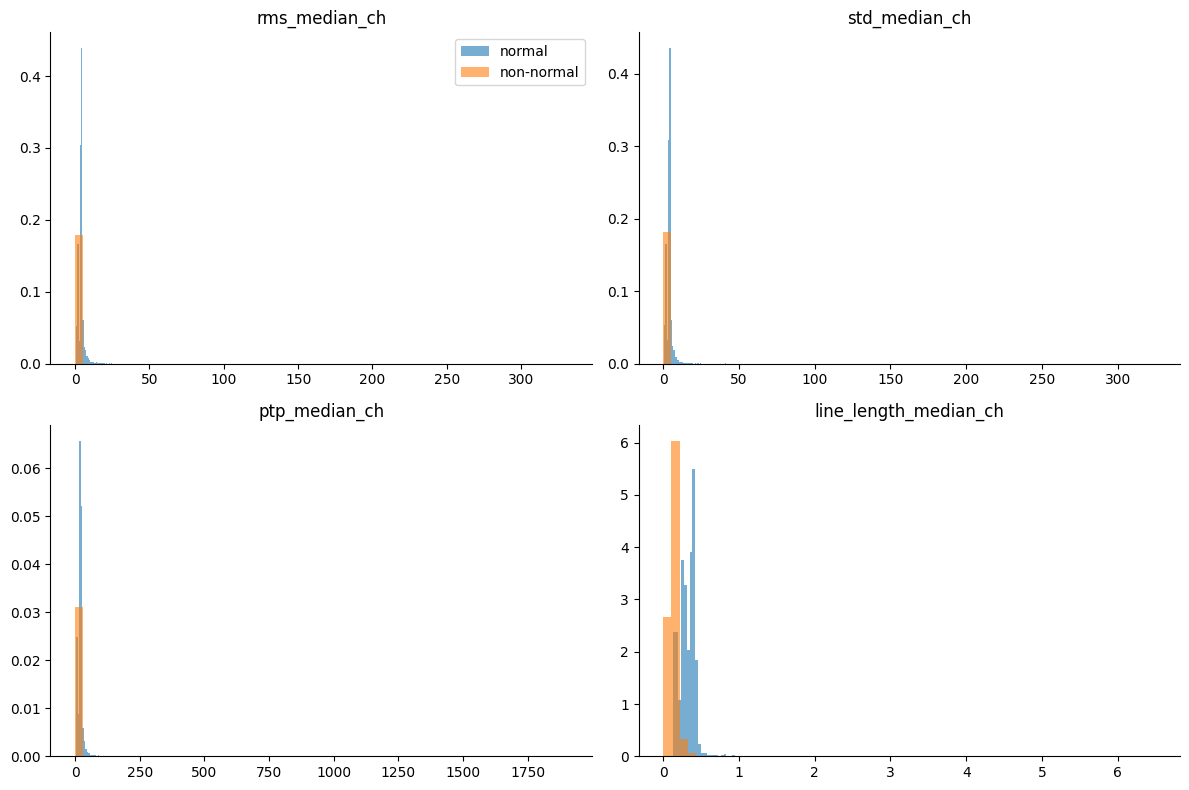

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
metrics = ['rms_median_ch', 'std_median_ch', 'ptp_median_ch', 'line_length_median_ch']
for ax, metric in zip(axs.ravel(), metrics):
    normal_vals = quality_df.loc[quality_df['label'] == 'normal', metric]
    non_vals = quality_df.loc[quality_df['label'] != 'normal', metric]
    ax.hist(normal_vals, bins=60, alpha=0.6, label='normal', density=True)
    ax.hist(non_vals, bins=60, alpha=0.6, label='non-normal', density=True)
    ax.set_title(metric)
    ax.spines[['top', 'right']].set_visible(False)
axs[0, 0].legend()
plt.tight_layout()
plt.show()

## 4) Define a plausible clean segment pool

A conservative and transparent rule for this tutorial:
1. Keep only segments labelled `normal`
2. Remove extreme metric outliers (outside 2nd to 98th percentile of the normal distribution for each metric)

You should adapt these thresholds based on your analysis goals and visual checks.

In [7]:
normal_df = quality_df[quality_df['label'] == 'normal'].copy()
metric_cols = ['rms_median_ch', 'std_median_ch', 'ptp_median_ch', 'line_length_median_ch']

keep_mask = np.ones(len(normal_df), dtype=bool)
thresholds = {}
for col in metric_cols:
    lo, hi = np.percentile(normal_df[col], [2, 98])
    thresholds[col] = (float(lo), float(hi))
    keep_mask &= (normal_df[col] >= lo) & (normal_df[col] <= hi)

clean_pool_df = normal_df.loc[keep_mask].copy()
clean_pool_df = clean_pool_df.sort_values('segment_index').reset_index(drop=True)

print('Total segments:', len(quality_df))
print('Normal segments:', len(normal_df))
print('Retained clean pool:', len(clean_pool_df))
print('Retention among normal segments: {:.1f}%'.format(100 * len(clean_pool_df) / len(normal_df)))
print('Thresholds used:', thresholds)

clean_pool_path = out_dir / 'clean_segment_pool.csv'
quality_path = out_dir / 'segment_quality_metrics.csv'
clean_pool_df.to_csv(clean_pool_path, index=False)
quality_df.to_csv(quality_path, index=False)

print('Saved:', clean_pool_path.resolve())
print('Saved:', quality_path.resolve())
clean_pool_df.head()

Total segments: 10000
Normal segments: 7284
Retained clean pool: 6827
Retention among normal segments: 93.7%
Thresholds used: {'rms_median_ch': (0.9972100489801559, 9.91259161552288), 'std_median_ch': (0.9962247658470396, 9.76251962558252), 'ptp_median_ch': (5.9876171875, 52.28953125000001), 'line_length_median_ch': (0.15196571374918008, 0.4702639350471077)}
Saved: /Users/k2477067/Documents/Repos/Aperiodic_EEG_Modelling/outputs/clean_segment_pool.csv
Saved: /Users/k2477067/Documents/Repos/Aperiodic_EEG_Modelling/outputs/segment_quality_metrics.csv


,segment_index,start_sample,start_time_s,label,rms_median_ch,std_median_ch,ptp_median_ch,line_length_median_ch
0,1,1000,5.0,normal,4.681343,4.635079,22.816406,0.372285
1,2,2000,10.0,normal,3.718803,3.710024,19.921875,0.398127
2,3,3000,15.0,normal,3.492342,3.485108,18.500000,0.344680
3,4,4000,20.0,normal,3.913951,3.913832,20.597656,0.355904
4,5,5000,25.0,normal,3.497442,3.494070,21.429688,0.263587


## Summary for later notebooks

- We inspected all segment labels and visualized representative normal/artifact segments.
- We computed simple, inspectable quality metrics for each segment.
- We retained a reproducible pool of plausible clean segments in `../outputs/clean_segment_pool.csv`.

In Tutorial 03, we will use this clean pool to compute Welch PSDs and compare them with stored spectra (`EEG_specs`, `EEG_frequency`).